In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess an example image
img_path = "example.jpg"  # Replace with your image path
img = load_img(img_path, target_size=(150, 150))  # Resize to uniform dimensions
img_array = img_to_array(img)  # Convert image to array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Initialize ImageDataGenerator with simple augmentation options
datagen = ImageDataGenerator(
    rotation_range=20,  # Rotate the image by up to 20 degrees
    width_shift_range=0.2,  # Shift the image horizontally by up to 20%
    height_shift_range=0.2,  # Shift the image vertically by up to 20%
    shear_range=0.15,  # Apply shear transformation
    zoom_range=0.2,  # Zoom in or out by up to 20%
    horizontal_flip=True,  # Flip the image horizontally
    fill_mode='nearest'  # Fill in new pixels with the nearest ones
)

# Generate augmented images
augmented_images = datagen.flow(img_array, batch_size=1)

# Visualize a few augmented images
plt.figure(figsize=(10, 10))
for i in range(9):  # Show 9 augmented images
    plt.subplot(3, 3, i + 1)
    batch = augmented_images.next()  # Generate the next augmented image
    plt.imshow(batch[0].astype('uint8'))  # Convert to uint8 format for visualization
    plt.axis('off')  # Remove axes
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'example.jpg'

In [2]:
#data augmentation on fashion mnist dataset

import numpy as np

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Reshape the data to add a channel dimension (needed for Conv2D layers)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

# Normalize pixel values to the range 0-1
X_train /= 255.0
X_test /= 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Data augmentation using ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10,          # Rotate images by up to 10 degrees
    width_shift_range=0.1,      # Shift images horizontally by up to 10%
    height_shift_range=0.1,     # Shift images vertically by up to 10%
    zoom_range=0.1,             # Zoom in/out by up to 10%
    horizontal_flip=False,      # Fashion MNIST images are not flipped
    fill_mode='nearest'         # Fill missing pixels with nearest neighbors
)

# Fit the generator on the training data
datagen.fit(X_train)

# Build a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with augmented data
batch_size = 64
epochs = 10

# Use the generator to augment the data on the fly during training
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size),
    validation_data=(X_test, y_test),
    steps_per_epoch=len(X_train) // batch_size,
    epochs=epochs
)

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Visualize some augmented images
augmented_images = datagen.flow(X_train[:9], batch_size=9).next()[0]

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Augmented Images", fontsize=16)
plt.show()


E:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


E:\Anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


937/937 ━━━━━━━━━━━━━━━━━━━━ 61s 60ms/step - accuracy: 0.6695 - loss: 0.8960 - val_accuracy: 0.8334 - val_loss: 0.4660
Epoch 2/10
  1/937 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.7031 - loss: 0.7736

E:\Anaconda\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7031 - loss: 0.7736 - val_accuracy: 0.8293 - val_loss: 0.4702
Epoch 3/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.8078 - loss: 0.5107 - val_accuracy: 0.8488 - val_loss: 0.4086
Epoch 4/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8125 - loss: 0.4503 - val_accuracy: 0.8508 - val_loss: 0.4065
Epoch 5/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.8294 - loss: 0.4513 - val_accuracy: 0.8668 - val_loss: 0.3634
Epoch 6/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7812 - loss: 0.4866 - val_accuracy: 0.8673 - val_loss: 0.3647
Epoch 7/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 55s 58ms/step - accuracy: 0.8504 - loss: 0.3993 - val_accuracy: 0.8568 - val_loss: 0.3744
Epoch 8/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7969 - loss: 0.5284 - val_accuracy: 0.8555 - val_loss: 0.3789
Epoch 9/10
937/937 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.8554 - loss: 0.3864 - val_accuracy: 0.882

AttributeError: 'NumpyArrayIterator' object has no attribute 'next'

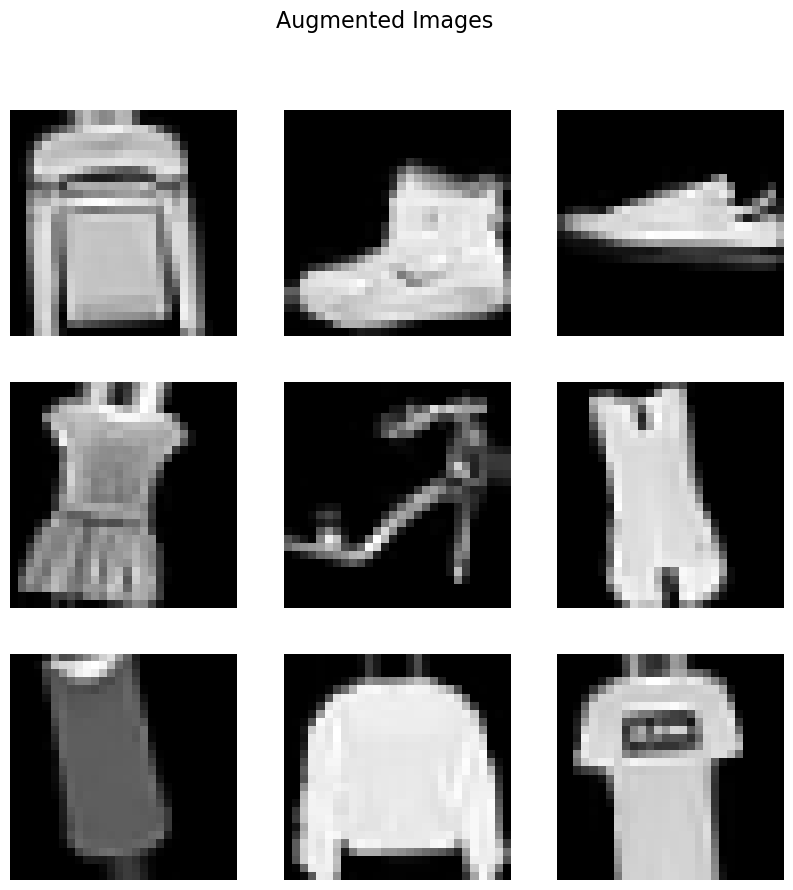

In [3]:
# Generate a batch of augmented images
augmented_images = next(datagen.flow(X_train[:9], batch_size=9))

# Visualize the augmented images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle("Augmented Images", fontsize=16)
plt.show()


In [5]:
import cv2

# Load the Haar cascade classifiers for face and eye detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Function for detecting face and eyes
def detect_face_and_eyes(frame):
    # Convert the frame to grayscale (required by the classifier)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    for (x, y, w, h) in faces:
        # Draw a rectangle around the face
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        
        # Region of interest for eyes within the detected face
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = frame[y:y + h, x:x + w]
        
        # Detect eyes within the face
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=10, minSize=(15, 15))
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)
    
    return frame

# Open the webcam (or use a video file)
video_capture = cv2.VideoCapture(0)  # Change to a file path for a video file

while True:
    # Capture frame-by-frame
    ret, frame = video_capture.read()
    if not ret:
        break
    
    # Detect face and eyes in the frame
    processed_frame = detect_face_and_eyes(frame)
    
    # Display the processed frame
    cv2.imshow('Face and Eye Detection', processed_frame)
    
    # Break the loop when 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the capture and close all OpenCV windows
video_capture.release()
cv2.destroyAllWindows()


In [6]:
#machine learning using knn
from sklearn import datasets

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [7]:
iris = datasets.load_iris()

In [8]:
features = iris.data

In [9]:
labels = iris.target

In [10]:
print(features[0],labels[0])

[5.1 3.5 1.4 0.2] 0


In [11]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [13]:
clf = KNeighborsClassifier()

In [14]:
clf.fit(features, labels)

KNeighborsClassifier()

In [19]:
preds = clf.predict([[31,1,1,1]])
preds

array([2])

In [20]:
print(preds)

[2]


In [22]:
preds = clf.predict([[9.1,9.5,6.4,0.2]])
print(preds)

[2]


In [23]:
a=55
a

55

In [24]:
type(a)

int

In [25]:
b=44
b

44

In [26]:
type(b)

int

In [27]:
c=1.5
c

1.5

In [28]:
d= True
d

True

In [29]:
type(d)

bool

In [30]:
e= (1,2,3,4,5)
e

(1, 2, 3, 4, 5)

In [31]:
type(e)

tuple

In [32]:
f=[1,2,3,5]
f

[1, 2, 3, 5]

In [33]:
import numpy as np

In [36]:
arr1  = np.array([12,14,16])
arr1

array([[12, 14, 16]])

In [37]:
print(arr1)

[[12 14 16]]


In [38]:
type(arr1)

numpy.ndarray

In [39]:
print(type(arr1))

<class 'numpy.ndarray'>


In [40]:
arr2 = np.array([12,2.5,"abc"])
arr2

array(['12', '2.5', 'abc'], dtype='<U32')

In [41]:
print(arr2)

['12' '2.5' 'abc']


In [42]:
print(type(arr2))

<class 'numpy.ndarray'>


In [43]:
arr3 = np.arange(12)
arr3

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [44]:
type(arr3)

numpy.ndarray

In [45]:
arr3.argmax

<function ndarray.argmax>

In [46]:
arr3.argmax()

11

In [47]:
arr3.argmin()

0

In [48]:
arr3.size()

TypeError: 'int' object is not callable

In [49]:
arr3.size

12

In [50]:
arr3.shape

(12,)

In [51]:
arr3.dtype

dtype('int32')

In [52]:
arr4 = np.array([[12,14],[16,18]])
print(arr4)

[[12 14]
 [16 18]]


In [53]:
print(type(arr4))

<class 'numpy.ndarray'>


In [54]:
print(arr4.dtype)

int32


In [55]:
print(arr4.shape)

(2, 2)


In [56]:
import pandas as pd

In [57]:
df = pd.DataFrame(12,14)
df

ValueError: DataFrame constructor not properly called!

In [58]:
df = pd.read_csv('data.txt')

In [59]:
df

,name,hours,marks
0,A,1,10
1,B,2,20
2,D,4,40


In [60]:
df.head()

,name,hours,marks
0,A,1,10
1,B,2,20
2,D,4,40


In [61]:
df.tail()

,name,hours,marks
0,A,1,10
1,B,2,20
2,D,4,40


In [62]:
type(df)

pandas.core.frame.DataFrame

In [63]:
df.shape()

TypeError: 'tuple' object is not callable

In [64]:
df.shape

(3, 3)

In [65]:
df.size

9

In [66]:
df.isnull.sum()

AttributeError: 'function' object has no attribute 'sum'

In [67]:
df.isnull().sum()

name     0
hours    0
marks    0
dtype: int64

In [68]:
df.describe()

,hours,marks
count,3.000000,3.000000
mean,2.333333,23.333333
std,1.527525,15.275252
min,1.000000,10.000000
25%,1.500000,15.000000
50%,2.000000,20.000000
75%,3.000000,30.000000
max,4.000000,40.000000


In [69]:
df.corr()

ValueError: could not convert string to float: 'A'

In [70]:
df.corr

<bound method DataFrame.corr of   name  hours  marks
0    A      1     10
1    B      2     20
2    D      4     40>

In [ ]:
df.r